# EDA Notebook

This notebook generates key plots used in the report.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
base_dir = Path.cwd().parent
cleaned = pd.read_csv(base_dir / '2_Data_Cleaning' / 'cleaned_data.csv', parse_dates=['datetime'])
features = pd.read_csv(base_dir / '4_Modeling' / 'user_features.csv')

display(cleaned.head())
display(features.head())

,source_file,user_id,date,time,datetime,direction,contact,phone,type,transaction_type,amount,currency,content,status,is_otp,is_promo
0,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-07,15:02:56,2024-06-07 15:02:56,received,MobileMoney,MobileMoney,SMS,balance,100.0,XAF,An adjustment has been made and 100 XAF has be...,success,False,False
1,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-08,17:27:07,2024-06-08 17:27:07,received,MobileMoney,MobileMoney,SMS,balance,8000.0,XAF,Vous avez recu 8000 XAF de IDA FALONE KENFACK ...,success,False,False
2,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-14,00:08:05,2024-06-14 00:08:05,received,MobileMoney,MobileMoney,SMS,balance,100.0,XAF,"Hello, the transaction with amount 100 XAF for...",failed,False,False
3,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-22,19:54:39,2024-06-22 19:54:39,received,MobileMoney,MobileMoney,SMS,balance,450.0,XAF,Vous avez recu 450 XAF de KLOUVIS TAHKEPE MAND...,success,False,False
4,Messages with MobileMoney 2026-03-20 190409.csv,msg_2026-03-20_190409,2024-06-23,09:48:39,2024-06-23 09:48:39,received,MobileMoney,MobileMoney,SMS,balance,10000.0,XAF,Vous avez recu 10000 XAF de LIWIR ELIAS (23765...,success,False,False


,user_id,total_transactions,total_transaction_volume,avg_transaction_amount,failed_transactions,deposit_amount,withdraw_amount,transfer_amount,payment_amount,airtime_amount,...,failed_ratio,business_usage,volume_norm,count_norm,avg_amount_norm,freq_norm,activity_score,activity_level,activity_threshold_low,activity_threshold_high
0,msg_2026-03-20_190409,1028,5972090.0,5809.426070,26,155213.0,0.0,0.0,1224.0,1759548.0,...,0.025292,1,3.138208e-06,1.000000,2.062074e-07,1.000000,0.450001,high,0.041317,0.11618
1,msg_2026-03-21_032328,227,1645355.0,7248.259912,5,0.0,0.0,0.0,800.0,473794.0,...,0.022026,1,8.626647e-07,0.216243,2.659884e-07,0.346850,0.123431,high,0.041317,0.11618
2,msg_2026-03-21_185556,40,3389367.0,84734.175000,3,0.0,0.0,610000.0,2005.0,48144.0,...,0.075000,1,1.779886e-06,0.033268,3.485387e-06,0.167560,0.041830,medium,0.041317,0.11618
3,msg_2026-03-21_195936,153,1922611.0,12566.084967,7,15130.0,0.0,0.0,925.0,703961.0,...,0.045752,1,1.008481e-06,0.143836,4.869343e-07,0.351039,0.106167,medium,0.041317,0.11618
4,msg_2026-03-22_213925,51,810073.0,15883.784314,0,0.0,0.0,0.0,0.0,33373.0,...,0.000000,1,4.233680e-07,0.044031,6.247786e-07,0.171582,0.045324,medium,0.041317,0.11618


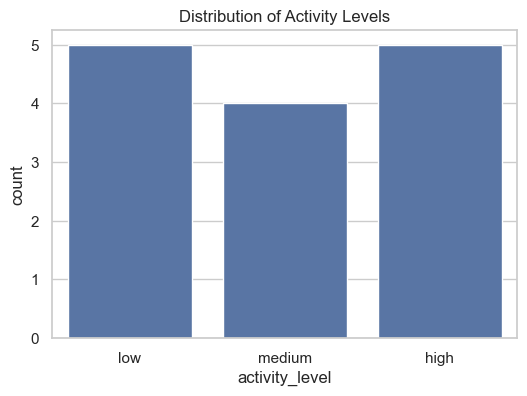

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(data=features, x='activity_level', order=['low', 'medium', 'high'])
plt.title('Distribution of Activity Levels')
plt.savefig('activity_level_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

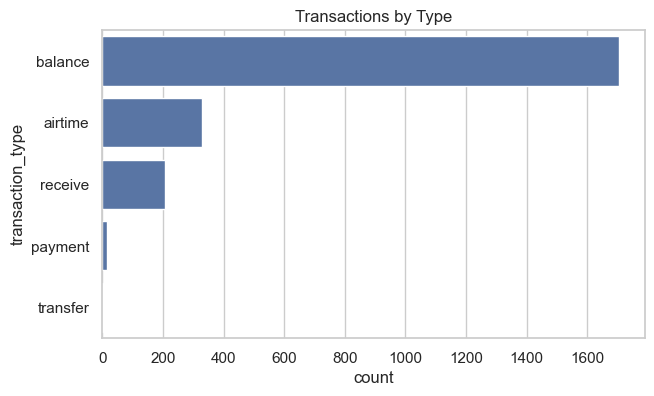

In [2]:
plt.figure(figsize=(7, 4))
order = cleaned['transaction_type'].value_counts().index
sns.countplot(data=cleaned, y='transaction_type', order=order)
plt.title('Transactions by Type')
plt.savefig('transactions_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

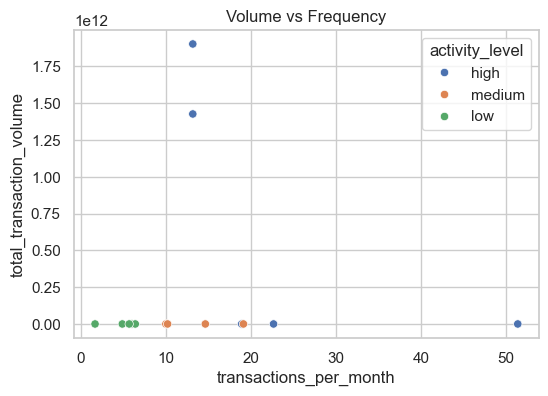

In [3]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=features, x='transactions_per_month', y='total_transaction_volume', hue='activity_level')
plt.title('Volume vs Frequency')
plt.savefig('volume_vs_frequency.png', dpi=300, bbox_inches='tight')
plt.show()